ROC-AUC Score: 0.5164


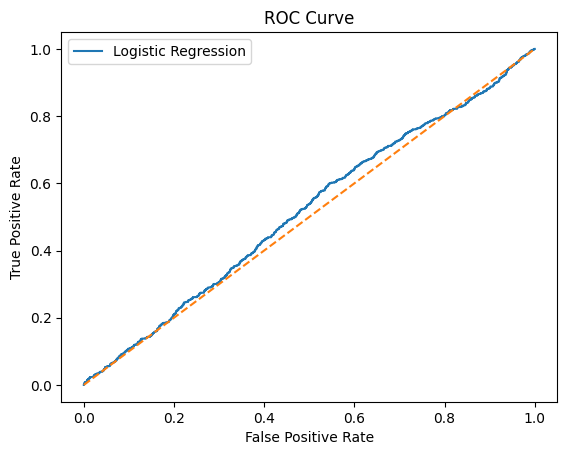

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve


df = pd.read_csv("hospital_readmissions_30k.csv")


df["readmitted_30_days"] = df["readmitted_30_days"].map({
    "Yes": 1,
    "No": 0
})


X = df[["age", "cholesterol", "bmi",
        "medication_count", "length_of_stay"]]


y = df["readmitted_30_days"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


model = LogisticRegression(
    penalty="l2",
    C=1.0
)


model.fit(X_train, y_train)


y_prob = model.predict_proba(X_test)[:, 1]


auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", round(auc, 4))


fpr, tpr, threshold = roc_curve(y_test, y_prob)

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()